- - -
# projek PCD 
- - -

## Preprocessing Citra Pipa Laut

Notebook ini melakukan preprocessing terhadap dataset citra pipa laut yang terdiri dari dua kelas, yaitu **Normal** dan **Corroded**. Tujuannya adalah menyiapkan citra agar lebih mudah dianalisis atau dilatih oleh model klasifikasi.

Semua tahapan dikerjakan dari nol menggunakan NumPy, tidak ada fungsi filter atau transformasi dari OpenCV maupun library image processing lainnya yang dipakai. OpenCV di sini hanya bertugas membaca file gambar dari disk, dan Matplotlib untuk menampilkan hasilnya.

Urutan pipeline yang diterapkan:

| No | Tahapan | Tujuan |
|----|---------|--------|
| 1 | **Resize** | Menyeragamkan ukuran semua citra menjadi 128×128 piksel |
| 2 | **Grayscale** | Mengubah citra berwarna menjadi abu-abu |
| 3 | **Histogram Equalization** | Meratakan distribusi kecerahan agar kontras lebih baik |
| 4 | **Sharpening** | Mempertajam tepi dan detail permukaan pipa |
| 5 | **Normalisasi** | Mengubah rentang nilai piksel ke 0–1 |

##  Import Library

Hanya tiga library yang dipakai di sini. `cv2` digunakan khusus untuk membaca file gambar dari disk karena ia bisa menangani berbagai format (JPG, PNG, BMP) secara efisien. `numpy` menangani semua operasi array dan perhitungan matematis. `matplotlib` digunakan di akhir untuk menampilkan hasil visualisasi. Tidak ada satu pun fungsi preprocessing yang berasal dari library luar.

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Konfigurasi Parameter

Sebelum masuk ke kode utama, kita definisikan dulu beberapa parameter global. `DATASET_PATH` menunjuk ke folder dataset yang di dalamnya terdapat subfolder `Normal` dan `Corroded`. Ukuran target 128×128 piksel dipilih karena cukup untuk menangkap detail tekstur permukaan pipa, tidak terlalu kecil sehingga informasi hilang, dan tidak terlalu besar sehingga proses preprocessing tidak berat.

In [2]:
DATASET_PATH = "dataset"
CLASSES      = ["Normal", "Corroded"]
TARGET_H     = 128
TARGET_W     = 128

##  Resize

Dataset citra pipa laut kemungkinan memiliki ukuran yang berbeda-beda tergantung kamera atau sumber pengambilan gambar. Sebelum diproses lebih lanjut, semua citra harus diseragamkan terlebih dahulu ke ukuran yang sama.

Fungsi ini mengimplementasikan **Nearest-Neighbor Interpolation** dari nol. Cara kerjanya: untuk setiap piksel di citra output, dihitung koordinat asalnya di citra input menggunakan rasio skala, lalu nilai piksel terdekat di koordinat tersebut diambil langsung tanpa interpolasi tambahan.

Misalnya, jika citra asli berukuran 640×480 dan target 128×128, maka setiap piksel output `(r, c)` akan mengambil nilai dari koordinat sumber `(r × 640/128, c × 480/128)` di citra asli.

Fungsi ini otomatis mendeteksi apakah citra berwarna (3 channel) atau grayscale (1 channel) dan menyesuaikan output-nya.

In [3]:
def resize_manual(image, new_h, new_w):
    src_h, src_w = image.shape[:2]
    is_color = image.ndim == 3
    if is_color:
        output = np.zeros((new_h, new_w, image.shape[2]), dtype=np.uint8)
    else:
        output = np.zeros((new_h, new_w), dtype=np.uint8)
    row_ratio = src_h / new_h
    col_ratio = src_w / new_w
    for r in range(new_h):
        for c in range(new_w):
            src_r = min(int(r * row_ratio), src_h - 1)
            src_c = min(int(c * col_ratio), src_w - 1)
            output[r, c] = image[src_r, src_c]
    return output

## Grayscale

Setelah di-resize, citra berwarna diubah menjadi grayscale. Konversi ke grayscale menyederhanakan data dari 3 channel menjadi 1 channel, sehingga proses berikutnya seperti histogram equalization dan sharpening lebih mudah diterapkan.

Konversi dilakukan menggunakan rumus standar **ITU-R BT.601** yang memperhitungkan sensitivitas mata manusia terhadap warna:

$$\text{Gray} = 0.299 \times R + 0.587 \times G + 0.114 \times B$$

Bobot berbeda karena mata manusia paling peka terhadap warna hijau, cukup peka terhadap merah, dan paling kurang peka terhadap biru. Perlu diperhatikan bahwa OpenCV menyimpan urutan channel sebagai BGR (bukan RGB), sehingga `channel[0]` adalah biru dan `channel[2]` adalah merah.

In [4]:
def grayscale_manual(image_bgr):
    B = image_bgr[:, :, 0].astype(np.float64)
    G = image_bgr[:, :, 1].astype(np.float64)
    R = image_bgr[:, :, 2].astype(np.float64)
    gray = 0.299 * R + 0.587 * G + 0.114 * B
    return np.clip(gray, 0, 255).astype(np.uint8)

##  Histogram Equalization

Citra pipa laut yang diambil di bawah air atau dalam kondisi pencahayaan buruk sering kali tampak terlalu gelap atau terlalu terang. Kondisi ini membuat detail penting, seperti tekstur karat, jadi sulit terlihat. Histogram Equalization mengatasi hal ini dengan meratakan distribusi kecerahan agar seluruh rentang nilai piksel (0–255) digunakan secara lebih proporsional.

Implementasinya dilakukan dalam tiga langkah:

**Langkah 1 Hitung Histogram**  
Dihitung berapa kali setiap nilai piksel (0 sampai 255) muncul di dalam citra. Hasilnya adalah array berisi 256 angka yang mewakili frekuensi kemunculan.

**Langkah 2 Hitung CDF (Cumulative Distribution Function)**  
Histogram dijumlahkan secara kumulatif dari kiri ke kanan. CDF menggambarkan berapa total piksel yang nilainya ≤ nilai tertentu.

**Langkah 3 Buat Lookup Table dan Terapkan**  
Setiap nilai piksel lama dipetakan ke nilai baru menggunakan rumus:

$$\text{lut}[i] = \text{round}\left(\frac{\text{CDF}[i] - \text{CDF}_{\min}}{N - \text{CDF}_{\min}} \times 255\right)$$

di mana $N$ adalah total jumlah piksel dan $\text{CDF}_{\min}$ adalah nilai CDF terkecil yang lebih dari nol. Setelah LUT terbentuk, setiap piksel citra dipetakan nilainya menggunakan tabel ini.

In [5]:
def histogram_equalization_manual(gray):
    hist = np.zeros(256, dtype=np.int64)
    for val in gray.flatten():
        hist[val] += 1

    total_pixels = gray.size
    cdf = np.zeros(256, dtype=np.float64)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    cdf_min = 0
    for i in range(256):
        if cdf[i] > 0:
            cdf_min = cdf[i]
            break

    lut = np.zeros(256, dtype=np.uint8)
    denom = total_pixels - cdf_min
    for i in range(256):
        if denom == 0:
            lut[i] = 0
        else:
            lut[i] = int(round(((cdf[i] - cdf_min) / denom) * 255))

    equalized = np.zeros_like(gray, dtype=np.uint8)
    rows, cols = gray.shape
    for r in range(rows):
        for c in range(cols):
            equalized[r, c] = lut[gray[r, c]]
    return equalized

## Sharpening

Setelah histogram equalization, kontras citra sudah lebih baik. Namun detail seperti tepi karat, retakan, atau batas permukaan pipa mungkin masih terlihat kurang tegas. Sharpening bertugas memperkuat perbedaan intensitas di area-area tersebut sehingga detail menjadi lebih tajam.

Sharpening dilakukan menggunakan **konvolusi Laplacian** dengan kernel 3×3:

$$K = \begin{bmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0 \end{bmatrix}$$

Cara kernel ini bekerja sangat intuitif: piksel tengah dikalikan 5, sedangkan empat tetangganya (atas, bawah, kiri, kanan) masing-masing dikalikan -1. Di area yang datar dan seragam, efeknya nol karena `5x − 4x = x`. Tapi di area yang ada perbedaan nilai piksel seperti tepi karat, perbedaan tersebut diperkuat, membuat batas dan detail lebih terlihat jelas.

Konvolusi dilakukan sepenuhnya manual menggunakan sliding window dengan double loop. Padding tipe `edge` diterapkan di tepi citra supaya piksel di pinggir tidak kehilangan konteks tetangganya dan tetap terproses dengan benar. Hasil akhir di-clip ke [0, 255] untuk mencegah overflow.

In [6]:
def sharpen_manual(gray):
    kernel = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ], dtype=np.float64)
    rows, cols = gray.shape
    padded = np.pad(gray.astype(np.float64), pad_width=1, mode='edge')
    output = np.zeros((rows, cols), dtype=np.float64)
    for r in range(rows):
        for c in range(cols):
            patch = padded[r:r+3, c:c+3]
            output[r, c] = np.sum(patch * kernel)
    return np.clip(output, 0, 255).astype(np.uint8)

##  Pipeline Preprocessing

Fungsi `preprocess()` merangkai semua tahapan di atas menjadi satu alur yang berjalan berurutan. Citra masuk dalam format BGR, kemudian melewati resize → grayscale → histogram equalization → sharpening, dan diakhiri dengan normalisasi ke rentang 0–1 agar nilainya siap dipakai oleh model machine learning.

Fungsi ini mengembalikan semua hasil, bukan hanya output akhir, sehingga kita bisa mengintip dan memverifikasi hasil di setiap tahapan.

In [7]:
def preprocess(image_bgr):
    resized    = resize_manual(image_bgr, TARGET_H, TARGET_W)
    gray       = grayscale_manual(resized)
    equalized  = histogram_equalization_manual(gray)
    sharpened  = sharpen_manual(equalized)
    normalized = sharpened / 255.0
    return resized, gray, equalized, sharpened, normalized

##  Load dan Proses Seluruh Dataset

Di sini kita membaca semua file gambar dari folder `dataset/Normal` dan `dataset/Corroded`, lalu menjalankan pipeline preprocessing untuk setiap gambar. Progress ditampilkan setiap 20 gambar agar kita bisa memantau prosesnya, mengingat proses manual dengan double loop memang membutuhkan waktu lebih lama dibanding fungsi bawaan library.

Semua hasil disimpan ke dalam dictionary `results` per kelas. Gambar pertama dari masing-masing kelas juga disimpan ke `sample_imgs` dan akan digunakan untuk visualisasi di tahap berikutnya.

In [8]:
results     = {}
sample_imgs = {}

for label in CLASSES:
    folder = os.path.join(DATASET_PATH, label)
    files  = [f for f in os.listdir(folder)
               if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    print(f"Kelas '{label}' — {len(files)} gambar ditemukan")
    processed = []
    for i, fname in enumerate(files):
        img_bgr = cv2.imread(os.path.join(folder, fname))
        if img_bgr is None:
            continue
        resized, gray, equalized, sharpened, normalized = preprocess(img_bgr)
        if label not in sample_imgs:
            sample_imgs[label] = img_bgr.copy()
        processed.append({
            "filename"  : fname,
            "resized"   : resized,
            "gray"      : gray,
            "equalized" : equalized,
            "sharpened" : sharpened,
            "normalized": normalized,
        })
        if (i + 1) % 20 == 0 or (i + 1) == len(files):
            print(f"  {i+1}/{len(files)} selesai")
    results[label] = processed
    print()

print("Seluruh dataset selesai diproses.")

Kelas 'Normal' — 120 gambar ditemukan


  20/120 selesai
  40/120 selesai
  60/120 selesai
  80/120 selesai
  100/120 selesai
  120/120 selesai

Kelas 'Corroded' — 121 gambar ditemukan
  20/121 selesai
  40/121 selesai
  60/121 selesai
  80/121 selesai
  100/121 selesai
  120/121 selesai
  121/121 selesai

Seluruh dataset selesai diproses.


## Visualisasi Tahapan Preprocessing

Untuk memastikan semua tahapan berjalan dengan benar, kita tampilkan satu sampel dari masing-masing kelas melewati seluruh pipeline secara berdampingan. Dari kiri ke kanan, kita bisa melihat perubahan citra mulai dari warna asli, hasil grayscale, perbaikan kontras setelah histogram equalization, hingga penajaman detail di tahap sharpening. Citra normalisasi di kolom terakhir menunjukkan representasi akhir dalam rentang 0–1.

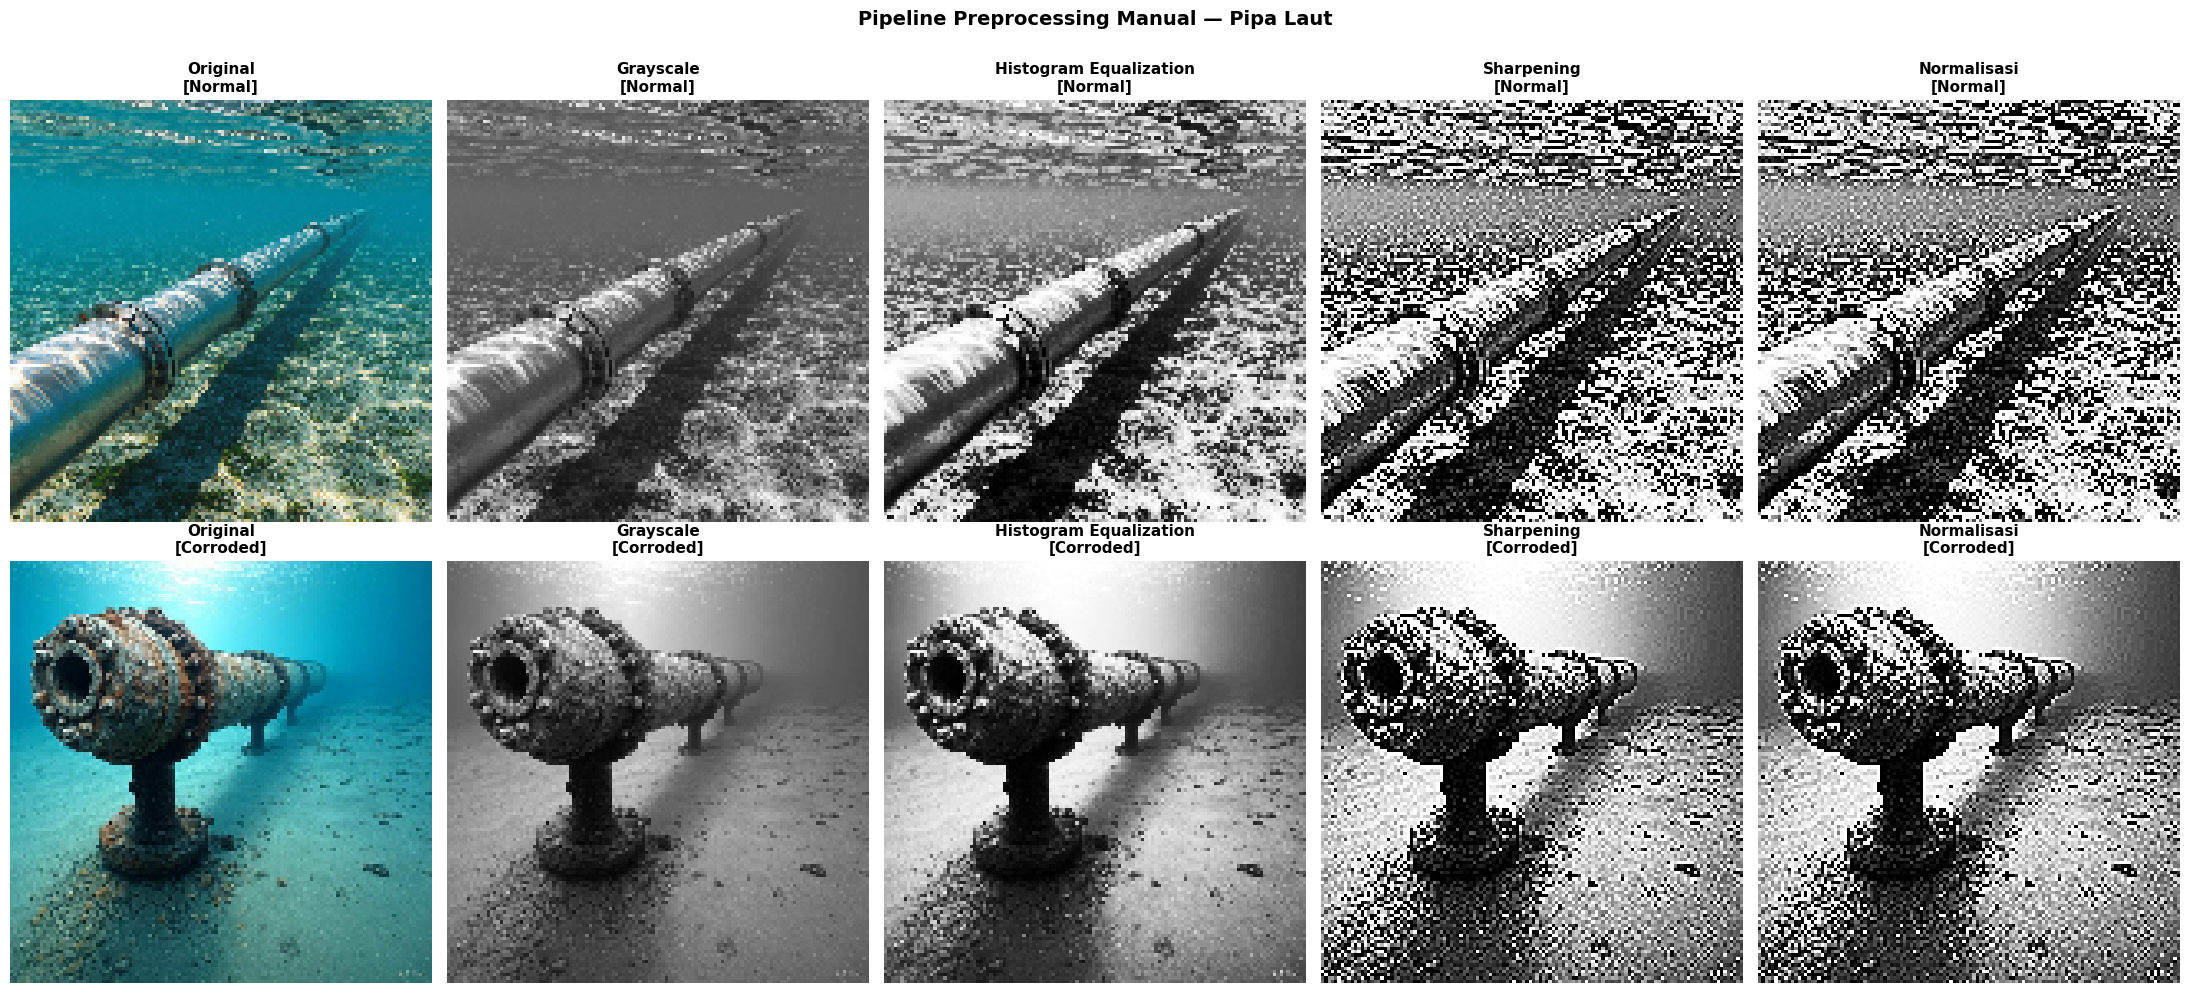

In [9]:
step_labels = ["Original", "Grayscale", "Histogram Equalization", "Sharpening", "Normalisasi"]
cmaps       = [None, "gray", "gray", "gray", "gray"]

fig, axes = plt.subplots(len(CLASSES), 5, figsize=(22, 5 * len(CLASSES)))
if len(CLASSES) == 1:
    axes = [axes]

for row, label in enumerate(CLASSES):
    img_bgr = sample_imgs[label]
    resized, gray, equalized, sharpened, normalized = preprocess(img_bgr)
    steps = [
        cv2.cvtColor(resized, cv2.COLOR_BGR2RGB),
        gray,
        equalized,
        sharpened,
        normalized,
    ]
    for col, (simg, title, cmap) in enumerate(zip(steps, step_labels, cmaps)):
        ax = axes[row][col]
        ax.imshow(simg, cmap=cmap, vmin=0, vmax=1 if col == 4 else None)
        ax.set_title(f"{title}\n[{label}]", fontsize=11, fontweight="bold")
        ax.axis("off")

fig.suptitle("Pipeline Preprocessing Manual — Pipa Laut", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("preprocessing_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualisasi Histogram Sebelum dan Sesudah Equalization

Grafik ini memperlihatkan secara langsung efek dari histogram equalization. Histogram sebelum equalization (biru) biasanya menumpuk di satu area, misalnya banyak piksel bernilai rendah jika citra gelap. Setelah equalization (hijau), distribusi nilai piksel seharusnya lebih merata di seluruh rentang 0–255, yang berarti kontras citra meningkat dan informasi visual lebih bisa dimanfaatkan secara optimal.

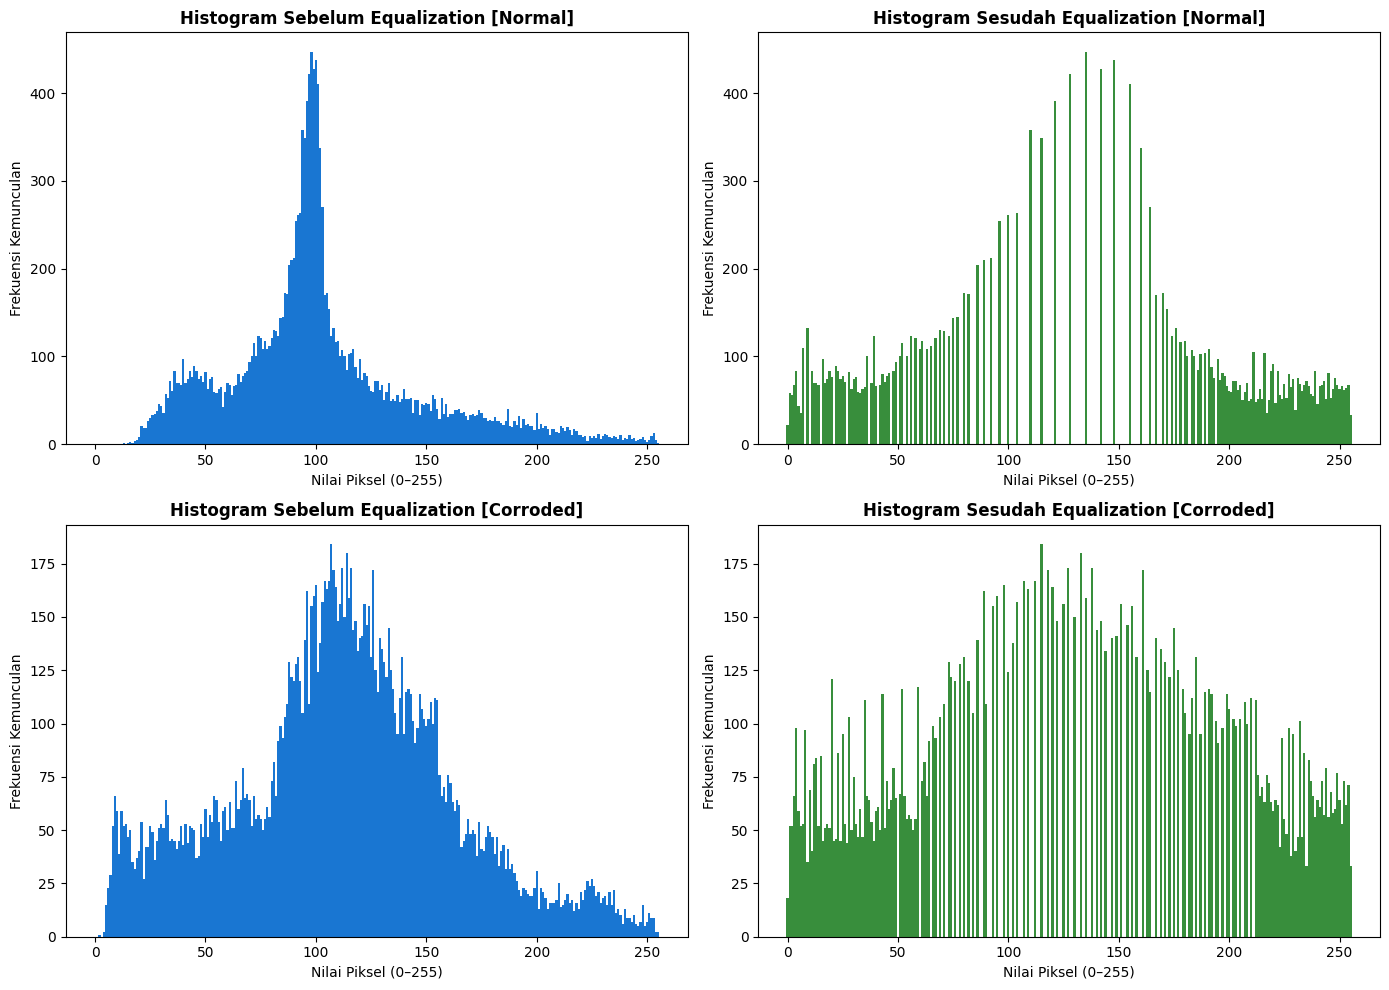

In [10]:
fig, axes = plt.subplots(len(CLASSES), 2, figsize=(14, 5 * len(CLASSES)))
if len(CLASSES) == 1:
    axes = [axes]

for row, label in enumerate(CLASSES):
    img_bgr = sample_imgs[label]
    resized, gray, equalized, _, _ = preprocess(img_bgr)

    hist_before = np.zeros(256, dtype=np.int64)
    for val in gray.flatten():
        hist_before[val] += 1

    hist_after = np.zeros(256, dtype=np.int64)
    for val in equalized.flatten():
        hist_after[val] += 1

    axes[row][0].bar(range(256), hist_before, color="#1976D2", width=1)
    axes[row][0].set_title(f"Histogram Sebelum Equalization [{label}]", fontweight="bold")
    axes[row][0].set_xlabel("Nilai Piksel (0–255)")
    axes[row][0].set_ylabel("Frekuensi Kemunculan")

    axes[row][1].bar(range(256), hist_after, color="#388E3C", width=1)
    axes[row][1].set_title(f"Histogram Sesudah Equalization [{label}]", fontweight="bold")
    axes[row][1].set_xlabel("Nilai Piksel (0–255)")
    axes[row][1].set_ylabel("Frekuensi Kemunculan")

plt.tight_layout()
plt.savefig("histogram_comparison.png", dpi=150, bbox_inches="tight")
plt.show()